<a href="https://colab.research.google.com/github/AlifHammam/data-science-2026/blob/main/Pertemuan4_AlifHammamMultazam_240401010043.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pertemuan 4 - Statistika Dasar & Analisis Data

**Nama Lengkap:** Alif Hammam Multazam  
**NIM:** 240401010043  
**Kelas:** IF403

## Langkah 1 — Load & Inspect Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = sns.load_dataset('iris')

print('Shape:', df.shape)
print(df.dtypes)
print(df.head())
print(df.describe().round(3))

Shape: (150, 5)
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
       sepal_length  sepal_width  petal_length  petal_width
count       150.000      150.000       150.000      150.000
mean          5.843        3.057         3.758        1.199
std           0.828        0.436         1.765        0.762
min           4.300        2.000         1.000        0.100
25%           5.100        2.800         1.600        0.300
50%           5.800        3.000         4.350        1.300
75%           6.400        3.300         5.100

## Langkah 2 — Statistik Deskriptif Lengkap

In [2]:
# Mean, Median, Std, Skewness, Kurtosis per kolom numerik
for col_name in df.select_dtypes(include='number').columns:
    col = df[col_name]
    print(f'\n=== {col_name} ===')
    print(f'  Mean      : {col.mean():.3f}')
    print(f'  Median    : {col.median():.3f}')
    print(f'  Std Dev   : {col.std():.3f}')
    print(f'  Varians   : {col.var():.3f}')
    print(f'  Skewness  : {col.skew():.3f}')
    print(f'  Kurtosis  : {col.kurt():.3f}')


=== sepal_length ===
  Mean      : 5.843
  Median    : 5.800
  Std Dev   : 0.828
  Varians   : 0.686
  Skewness  : 0.315
  Kurtosis  : -0.552

=== sepal_width ===
  Mean      : 3.057
  Median    : 3.000
  Std Dev   : 0.436
  Varians   : 0.190
  Skewness  : 0.319
  Kurtosis  : 0.228

=== petal_length ===
  Mean      : 3.758
  Median    : 4.350
  Std Dev   : 1.765
  Varians   : 3.116
  Skewness  : -0.275
  Kurtosis  : -1.402

=== petal_width ===
  Mean      : 1.199
  Median    : 1.300
  Std Dev   : 0.762
  Varians   : 0.581
  Skewness  : -0.103
  Kurtosis  : -1.341


In [3]:
# Kuartil, Persentil & IQR untuk sepal_length
col = df['sepal_length']

Q1 = col.quantile(0.25)
Q2 = col.quantile(0.50)
Q3 = col.quantile(0.75)
IQR = Q3 - Q1

print(f'Q1={Q1:.2f}, Q2={Q2:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}')

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = col[(col < lower) | (col > upper)]
print(f'Outlier: {len(outliers)} baris')
print(col.quantile([0.1, 0.25, 0.5, 0.75, 0.9]).round(2))

Q1=5.10, Q2=5.80, Q3=6.40, IQR=1.30
Outlier: 0 baris
0.10    4.8
0.25    5.1
0.50    5.8
0.75    6.4
0.90    6.9
Name: sepal_length, dtype: float64


## Langkah 3 — Analisis Distribusi (Histogram + KDE)

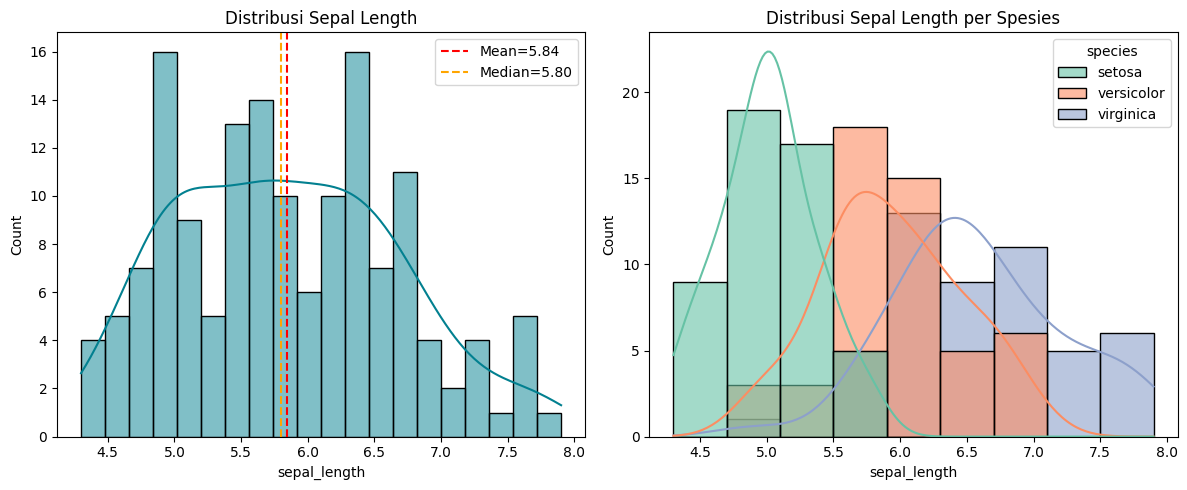

Skewness: 0.315 → distribusi simetris
Kurtosis: -0.552


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram + KDE sepal_length dengan garis mean & median
sns.histplot(df['sepal_length'], kde=True, color='#028090', bins=20, ax=axes[0])
axes[0].axvline(df['sepal_length'].mean(),   color='red',    linestyle='--',
                label=f"Mean={df['sepal_length'].mean():.2f}")
axes[0].axvline(df['sepal_length'].median(), color='orange', linestyle='--',
                label=f"Median={df['sepal_length'].median():.2f}")
axes[0].set_title('Distribusi Sepal Length')
axes[0].legend()

# Histogram + KDE per spesies
sns.histplot(data=df, x='sepal_length', hue='species',
             kde=True, palette='Set2', alpha=0.6, ax=axes[1])
axes[1].set_title('Distribusi Sepal Length per Spesies')

plt.tight_layout()
plt.show()

# Skewness & kurtosis
sk = df['sepal_length'].skew()
ku = df['sepal_length'].kurt()
print(f'Skewness: {sk:.3f} → distribusi {"simetris" if abs(sk) < 0.5 else "miring kanan" if sk > 0 else "miring kiri"}')
print(f'Kurtosis: {ku:.3f}')

## Langkah 4 — Boxplot & Violin Plot per Spesies

/tmp/ipykernel_1180/1460986993.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y='petal_length',
/tmp/ipykernel_1180/1460986993.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='species', y='petal_length',


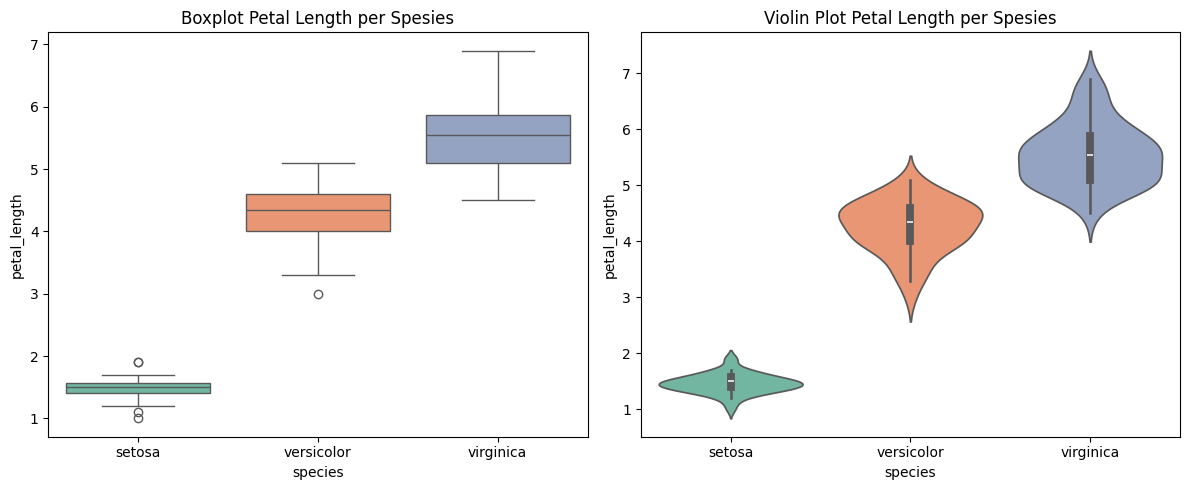

             mean  min  max    std
species                           
setosa      1.462  1.0  1.9  0.174
versicolor  4.260  3.0  5.1  0.470
virginica   5.552  4.5  6.9  0.552


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df, x='species', y='petal_length',
            palette='Set2', ax=axes[0])
axes[0].set_title('Boxplot Petal Length per Spesies')

sns.violinplot(data=df, x='species', y='petal_length',
               palette='Set2', inner='box', ax=axes[1])
axes[1].set_title('Violin Plot Petal Length per Spesies')

plt.tight_layout()
plt.show()

# Identifikasi nilai per spesies
print(df.groupby('species')['petal_length'].agg(['mean','min','max','std']).round(3))

## Langkah 5 — Matriks Korelasi Pearson & Spearman

In [6]:
# Korelasi Pearson & Spearman untuk sepal_length vs petal_length
x = df['sepal_length']
y = df['petal_length']

r,   p_r = stats.pearsonr(x, y)
rho, p_s = stats.spearmanr(x, y)

print(f'Pearson  r = {r:.4f}  (p = {p_r:.6f})')
print(f'Spearman ρ = {rho:.4f} (p = {p_s:.6f})')

# Matriks korelasi
corr = df.drop('species', axis=1).corr(method='pearson')
print('\nMatriks Korelasi Pearson:')
print(corr.round(3))

# Pasangan dengan korelasi tertinggi
mask = np.triu(np.ones(corr.shape, dtype=bool))
corr_masked = corr.where(~mask)
max_pair = corr_masked.stack().idxmax()
print(f'\nKorelasi tertinggi: {max_pair} = {corr.loc[max_pair]:.3f}')

Pearson  r = 0.8718  (p = 0.000000)
Spearman ρ = 0.8819 (p = 0.000000)

Matriks Korelasi Pearson:
              sepal_length  sepal_width  petal_length  petal_width
sepal_length         1.000       -0.118         0.872        0.818
sepal_width         -0.118        1.000        -0.428       -0.366
petal_length         0.872       -0.428         1.000        0.963
petal_width          0.818       -0.366         0.963        1.000

Korelasi tertinggi: ('petal_width', 'petal_length') = 0.963


## Langkah 6 — Scatter Plot & Heatmap Korelasi

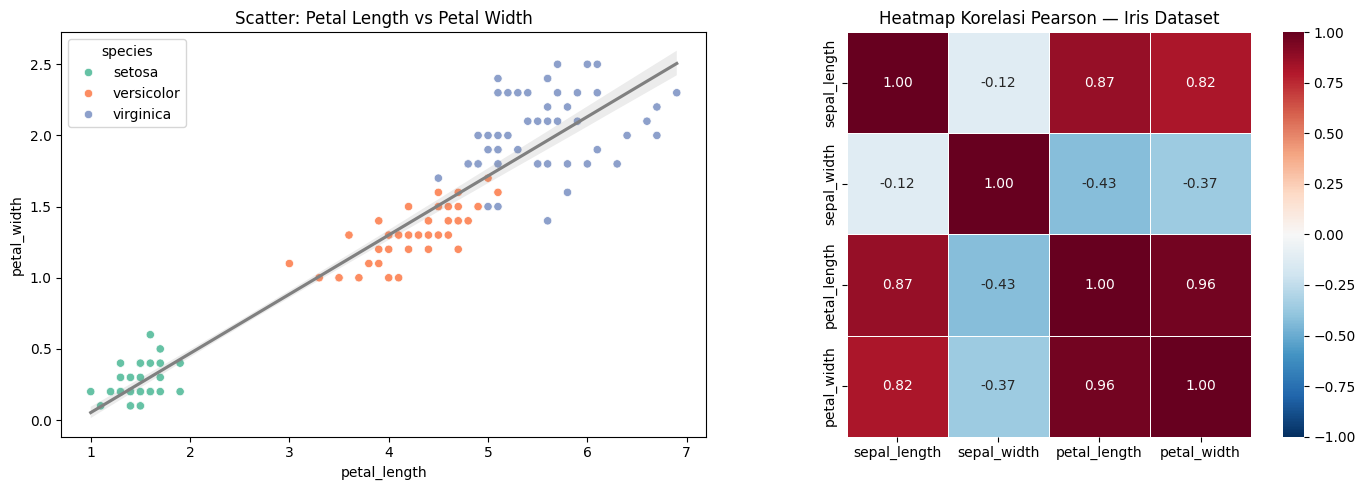

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot petal_length vs petal_width
sns.scatterplot(data=df, x='petal_length', y='petal_width',
                hue='species', palette='Set2', ax=axes[0])
sns.regplot(data=df, x='petal_length', y='petal_width',
            scatter=False, color='gray', ax=axes[0])
axes[0].set_title('Scatter: Petal Length vs Petal Width')

# Heatmap korelasi
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=-1, vmax=1, square=True,
            linewidths=0.5, linecolor='white', ax=axes[1])
axes[1].set_title('Heatmap Korelasi Pearson — Iris Dataset')

plt.tight_layout()
plt.show()

### Interpretasi

Dari heatmap terlihat bahwa `petal_length` dan `petal_width` memiliki korelasi Pearson tertinggi (r ≈ 0.96), yang berarti hubungannya sangat kuat dan positif. Artinya, semakin panjang mahkota bunga, semakin lebar pula mahkota tersebut. Sebaliknya, `sepal_width` hampir tidak berkorelasi dengan variabel lainnya, menunjukkan bahwa lebar kelopak tidak terlalu berpengaruh terhadap ukuran dimensi lain pada bunga iris.

## Kesimpulan

Pada praktikum pertemuan keempat ini saya mempelajari konsep statistika deskriptif seperti mean, median, modus, varians, standar deviasi, skewness, dan kurtosis, serta cara menerapkannya menggunakan Python pada dataset Iris.

Melalui analisis univariat dan bivariat, saya memahami cara membaca distribusi data menggunakan histogram dan KDE, membandingkan distribusi antar kelompok lewat boxplot dan violin plot, serta mengukur hubungan antar variabel dengan korelasi Pearson dan Spearman. Dari hasil analisis ditemukan bahwa `petal_length` dan `petal_width` memiliki korelasi yang sangat kuat (r ≈ 0.96), dan spesies virginica cenderung memiliki ukuran petal yang paling besar dibandingkan dua spesies lainnya.

Keterbatasan pada praktikum ini adalah analisis masih terbatas pada satu dataset yang relatif bersih dan sederhana, sehingga belum mencerminkan kompleksitas data nyata. Namun, praktikum ini sangat membantu dalam membangun fondasi pemahaman statistika yang akan dibutuhkan pada tahap pemodelan data selanjutnya.